In [1]:
# we will make a simple workflow BMI using langgraph
#Start->calculate_bmi->End

In [ ]:
from langgraph.graph import StateGraph,START,END
#from pydantic import BaseModel, Field
from typing import TypedDict


In [17]:
#define the state schema
class BMIState(TypedDict):
    weight: float
    height: float
    bmi:float
    category:str

In [18]:
def calculate_bmi(state: BMIState) -> BMIState:
    state["bmi"] = round(state["weight"] / (state["height"] ** 2), 2)
    return state

In [19]:
def check_bmi(state: BMIState) -> BMIState:
    if state["bmi"] < 18.5:
        state["category"] = "Underweight"
    elif 18.5 <= state["bmi"] < 25:
        state["category"] = "Normal weight"
    elif 25 <= state["bmi"] < 30:
        state["category"] = "Overweight"
    else:
        state["category"] = "Obesity"
    return state

In [20]:
#define the graph
graph = StateGraph(BMIState)
#add nodes
graph.add_node("calculate_bmi", calculate_bmi)
graph.add_node("check_bmi", check_bmi)
#add edges
graph.add_edge(START, "calculate_bmi")
graph.add_edge("calculate_bmi", "check_bmi")
graph.add_edge("check_bmi", END)
#compile graph
workflow= graph.compile()
#execute graph
#

In [21]:
#execute graph
intial_state = {"weight": 70, "height": 1.75}

finalstate= workflow.invoke(intial_state)

print(finalstate)

{'weight': 70, 'height': 1.75, 'bmi': 22.86, 'category': 'Normal weight'}


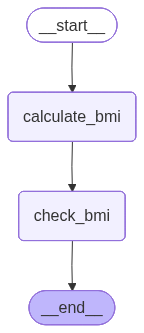

In [22]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())